# CIM Assignment 2 - Experiments with visual signals compression techniques


**Course**: Multimedia Information Codification  
**Academic Year**: 2025/2026    
**Authors**: Guilherme Rodrigues 202208878, João Oliveira 202205302         
**Date**: March 2026

## Importing libraries

In [135]:

import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import warnings
from scipy.fft import dctn, idctn # To do Discrete Cosine Transform

# Defining the paths and extensions
folder_path = './images_assignment2/'
extensions = ('.jpg', '.png', '.tif', '.bmp')

## TASK 1 
### 1.1 


## TASK 2 - Experiments with transform coding and quantisation
### 2.1 - Basis

In [136]:
# Create a list of images
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(extensions)] 

# Selection for different color spaces 
clr_space = 0 # 0 for YCrCb; 1 for LAB; 2 for VHS  

# Function responsible for the conversion
def convert(img_path,clr_space = 0):
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    if (clr_space == 0):
        img_converted = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)
        names = 'YCrCb'
    elif (clr_space == 1):
        img_converted = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
        names = 'LAB'
    elif (clr_space == 2):
        img_converted = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
        names = 'HSV'

    return cv2.split(img_converted), names, img_rgb



### 2.1.i. Creating DCT transformated blocks


In [137]:
def get_dct_blocks(lum_channel):
    height, width = lum_channel.shape # The image should be a multiple of 8
    h_blocks, w_blocks = height//8, width//8
    dct_blocks = np.zeros((h_blocks,w_blocks,8,8))

    for i in range(h_blocks):
        for j in range(w_blocks):
            block = lum_channel[i*8:(i+1)*8, j*8:(j+1)*8].astype(float)
            dct_blocks[i, j] = dctn(block, norm='ortho') # The same as doing T.Block.T'. Orthogonalized variant
            
    return dct_blocks, (h_blocks, w_blocks)


### 2.1.ii. Creating DCT transformated blocks


In [138]:

def zigzag_order():
    return [
    (0,0), (0,1), (1,0), (2,0), (1,1), (0,2), (0,3), (1,2), (2,1), (3,0), (4,0), (3,1), (2,2), (1,3), (0,4), (0,5),
    (1,4), (2,3), (3,2), (4,1), (5,0), (6,0), (5,1), (4,2), (3,3), (2,4), (1,5), (0,6), (0,7), (1,6), (2,5), (3,4),
    (4,3), (5,2), (6,1), (7,0), (7,1), (6,2), (5,3), (4,4), (3,5), (2,6), (1,7), (2,7), (3,6), (4,5), (5,4), (6,3),
    (7,2), (7,3), (6,4), (5,5), (4,6), (3,7), (4,7), (5,6), (6,5), (7,4), (7,5), (6,6), (5,7), (6,7), (7,6), (7,7)
    ]



def first_k(dct_blocks, E_threshold):
    height_b, width_b, _, _ = dct_blocks.shape
    k_values = []

    ZIGZAG_ORDER = zigzag_order()

    for i in range(height_b):
        for j in range(width_b):
            block = dct_blocks[i,j]
            coeffs = np.array([block[pos] for pos in ZIGZAG_ORDER]) # Spreading the coefficients in zig-zag order
            energies = coeffs**2
            total_block_energy = np.sum(energies) # Energy= Summation ||Cij||2 ?

            cumulative_energy = np.cumsum(energies)

            k = np.where(cumulative_energy >= E_threshold*total_block_energy)[0][0] + 1 # [0][0] to select the first case
            k_values.append(k)

    return int(np.mean(k_values))

### 2.1.iii. Inverse transform


In [139]:
def reconstruct_image (dct_blocks, k, h_blocks, w_blocks):
    recovered = np.zeros((h_blocks*8, w_blocks*8))

    ZIGZAG_ORDER = zigzag_order()

    for i in range(h_blocks):
        for j in range(w_blocks):
            block = dct_blocks[i, j]
            coeffs = np.array([block[pos] for pos in ZIGZAG_ORDER])
            compressed_coeffs = np.zeros(64)
            compressed_coeffs[:k] = coeffs[:k] # To select the first k elements

            # Put back into 8x8 block 
            new_block = np.zeros((8,8))
            for idx, pos in enumerate(ZIGZAG_ORDER):
                new_block[pos] = compressed_coeffs[idx]
            
            # Inverse DCT
            recovered[i*8:(i+1)*8, j*8:(j+1)*8] = idctn(new_block, norm='ortho') 

    return recovered

### 2.1. Main code


For lighthouse.png, keeping 2/64 coefficients to reach 95.0% energy.


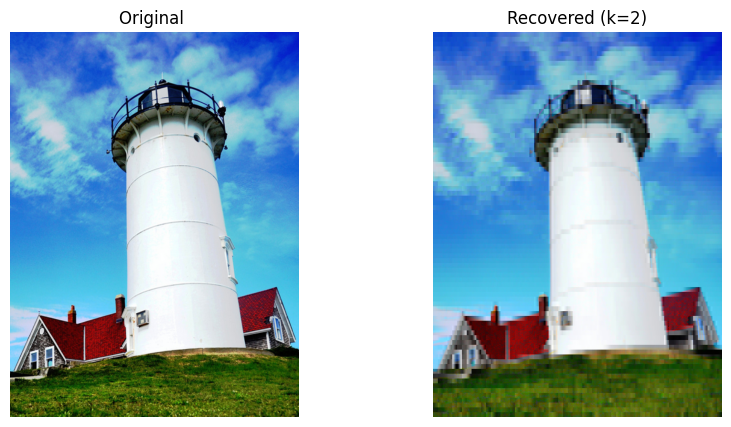

For parkavenue.jpg, keeping 1/64 coefficients to reach 95.0% energy.


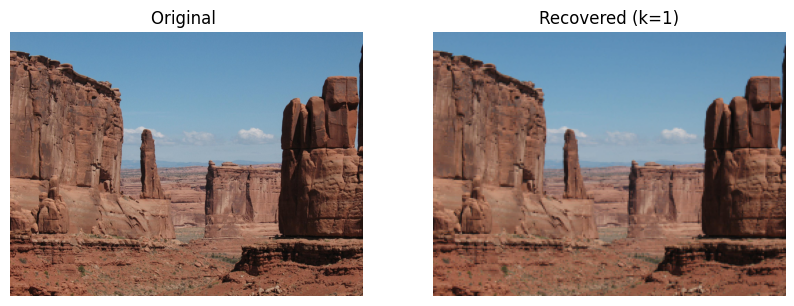

For baboon.png, keeping 4/64 coefficients to reach 95.0% energy.


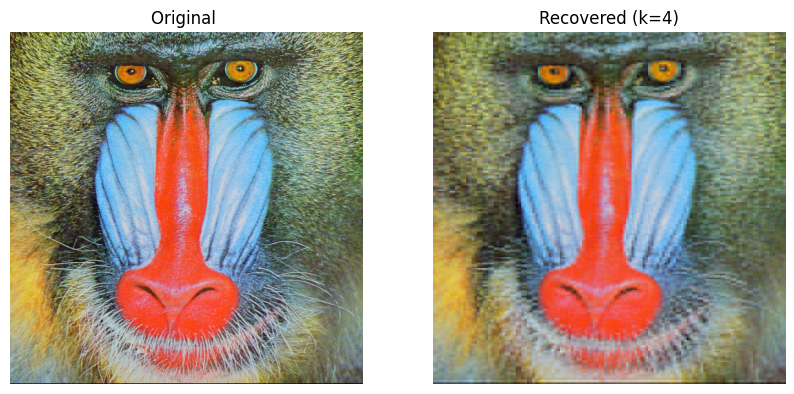

For Barbara.jpg, keeping 1/64 coefficients to reach 95.0% energy.


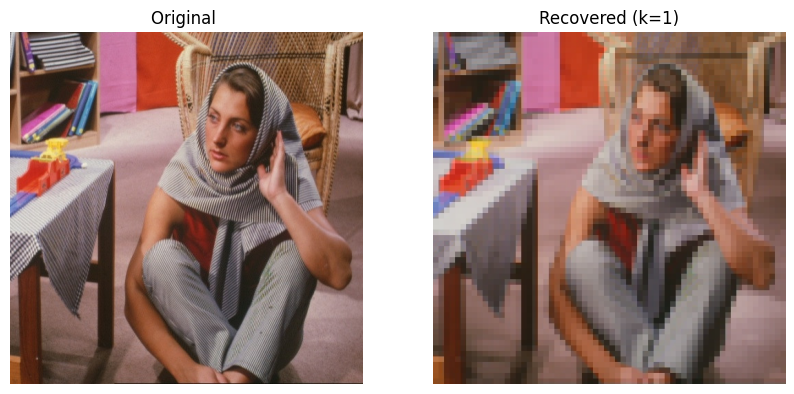

For saturn.png, keeping 2/64 coefficients to reach 95.0% energy.


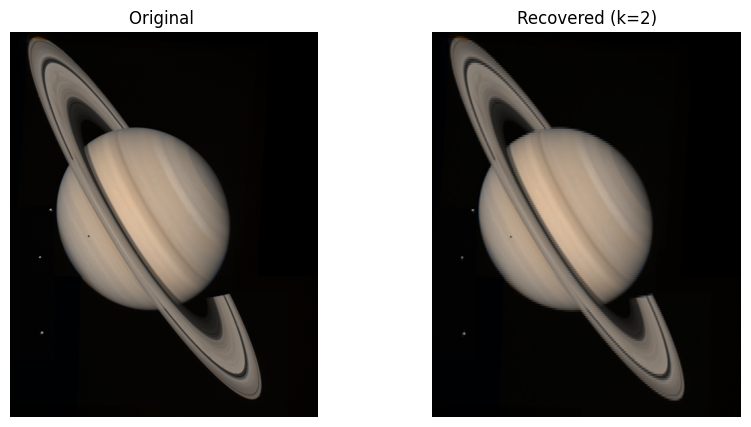

For praia.bmp, keeping 2/64 coefficients to reach 95.0% energy.


In [ ]:
E_threshold = 0.95

for filename in image_files:
    # 2.1 Basis
    path = os.path.join(folder_path, filename)
    channels, titles, original_img = convert(path, clr_space)
    Y = channels[0]

    # 2.1.i)
    dct_blocks, (h_b, w_b) = get_dct_blocks(Y)

    # 2.1.ii) 
    k_to_use = first_k(dct_blocks, E_threshold)
    print(f"For {filename}, keeping {k_to_use}/64 coefficients to reach {E_threshold*100}% energy.")

    #2.1.iii)
    recovered = reconstruct_image(dct_blocks, k_to_use, h_b, w_b)

    # Merge back for display 
    h_final, w_final = recovered.shape

    final_img_pre_rgb = cv2.merge([
        recovered.clip(0, 255).astype(np.uint8), # Just to make sure the values do not surpass 2^8
        channels[1][:h_final, :w_final],
        channels[2][:h_final, :w_final]
    ])

    if clr_space == 0 :
        final_img = cv2.cvtColor(final_img_pre_rgb, cv2.COLOR_YCrCb2RGB)
    elif clr_space == 1:
        final_img = cv2.cvtColor(final_img_pre_rgb, cv2.COLOR_LAB2RGB)
    elif clr_space == 2:
        final_img = cv2.cvtColor(final_img_pre_rgb, cv2.COLOR_HSV2RGB)

    # Plotting
    plt.figure(figsize=(10, 5))
    plt.title(titles)
    plt.subplot(1, 2, 1); plt.imshow(original_img); plt.title("Original "); plt.axis("off")
    plt.subplot(1, 2, 2); plt.imshow(final_img); plt.title(f"Recovered (k={k_to_use})"); plt.axis("off")
    plt.show()